In [11]:
# 下载动漫数据集（使用Kaggle Anime Faces Dataset）
# 如果本地没有数据集，可以通过以下方式下载
import requests
import zipfile
import os


# 如果数据集已存在则跳过下载
if not os.path.exists('../data/anime_faces/archive/data'):
    # 这里需要您手动下载数据集或提供路径
    # 建议从 https://www.kaggle.com/soumikrakshit/anime-faces 下载
    print("请从Kaggle下载动漫数据集并解压到 data/anime_faces/archive/data 目录")
    print("或者使用以下代码加载现有的数据集")

请从Kaggle下载动漫数据集并解压到 data/anime_faces/archive/data 目录
或者使用以下代码加载现有的数据集


使用设备: cuda
使用动漫数据集
数据批次形状示例: torch.Size([3, 64, 64])
图像通道数: 3
DCGAN生成器参数量: 3600707
DCGAN判别器参数量: 2766529
开始训练DCGAN...


Epoch 5/50: 100%|██████████████████████████████████████████| 336/336 [00:11<00:00, 29.51it/s, g_loss=2.45, d_loss=0.397]


已保存DCGAN样本图像: dcgan_samples_epoch_5.png


Epoch 10/50: 100%|██████████████████████████████████████████| 336/336 [00:11<00:00, 29.96it/s, g_loss=2.1, d_loss=0.418]


已保存DCGAN样本图像: dcgan_samples_epoch_10.png


...

已保存DCGAN样本图像: dcgan_samples_epoch_40.png


Epoch 45/50: 100%|█████████████████████████████████████████| 336/336 [00:12<00:00, 27.65it/s, g_loss=2.63, d_loss=0.349]


已保存DCGAN样本图像: dcgan_samples_epoch_45.png


Epoch 50/50: 100%|█████████████████████████████████████████| 336/336 [00:12<00:00, 27.53it/s, g_loss=0.95, d_loss=0.543]


已保存DCGAN样本图像: dcgan_samples_epoch_50.png


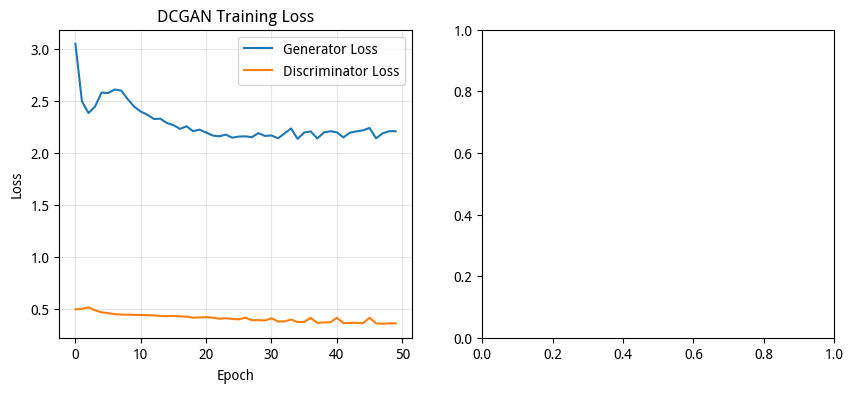

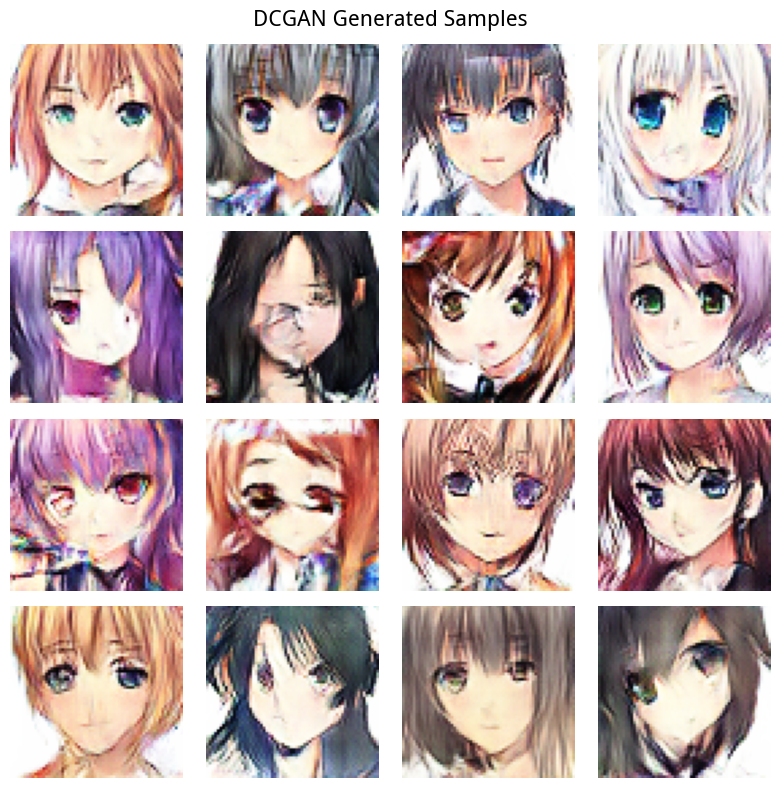

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from tqdm import tqdm

# 设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# 创建数据目录（如果需要）
os.makedirs('data/anime_faces', exist_ok=True)

# 修正的DCGAN生成器
class DCGAN_Generator(nn.Module):
    def __init__(self, latent_dim=100, img_channels=3):
        super(DCGAN_Generator, self).__init__()
        
        self.init_size = 4  # 初始特征图大小（调整为4）
        self.l1 = nn.Sequential(
            nn.Linear(latent_dim, 512 * self.init_size * self.init_size),
            nn.BatchNorm1d(512 * self.init_size * self.init_size),
            nn.ReLU(inplace=True)
        )
        
        self.conv_blocks = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            
            nn.ConvTranspose2d(64, img_channels, 4, stride=2, padding=1),
            nn.Tanh()
        )
    
    def forward(self, z):
        out = self.l1(z)
        out = out.view(out.shape[0], 512, self.init_size, self.init_size)
        img = self.conv_blocks(out)
        return img

class DCGAN_Discriminator(nn.Module):
    def __init__(self, img_channels=3):
        super(DCGAN_Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(img_channels, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, 4, stride=1, padding=0),
            nn.Sigmoid()
        )
    def forward(self, img):
        validity = self.model(img)
        return validity.view(-1, 1)
    

# 修正的训练函数
def train_dcgan(generator, discriminator, dataloader, epochs=100, latent_dim=100):
    # 优化：切换为LSGAN损失
    adversarial_loss = nn.BCELoss().to(device)
    
    optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0001, betas=(0.5, 0.999))
    
    generator.to(device)
    discriminator.to(device)
    history = {'g_loss': [], 'd_loss': []}

    for epoch in range(epochs):
        g_loss_epoch = 0
        d_loss_epoch = 0
        num_batches = 0
        
        pbar = tqdm(dataloader, desc=f'Epoch {epoch+1}/{epochs}')
        for i, batch_data in enumerate(pbar):
            # 数据处理
            if isinstance(batch_data, tuple) and len(batch_data) == 2:
                imgs, _ = batch_data
            else:
                imgs = batch_data
            
            batch_size = imgs.shape[0]
            real_imgs = imgs.to(device)
            
            # 标签平滑
            valid = torch.full((batch_size, 1), 0.9).to(device)
            fake = torch.full((batch_size, 1), 0.1).to(device)
            
            z = torch.randn(batch_size, latent_dim).to(device)
            gen_imgs = generator(z)

            # ----------------- 训练判别器 -----------------
            optimizer_D.zero_grad()
            real_loss = adversarial_loss(discriminator(real_imgs), valid)
            fake_loss = adversarial_loss(discriminator(gen_imgs.detach()), fake)
            d_loss = (real_loss + fake_loss) / 2
            d_loss.backward()
            optimizer_D.step()

            # ----------------- 训练生成器（特征匹配） -----------------
            optimizer_G.zero_grad()
            g_loss = adversarial_loss(discriminator(gen_imgs), valid)
            g_loss.backward()
            optimizer_G.step()

            # 记录损失
            g_loss_epoch += g_loss.item()
            d_loss_epoch += d_loss.item()
            num_batches += 1
            pbar.set_postfix({'g_loss': g_loss.item(), 'd_loss': d_loss.item()})
        
        # 保存损失
        history['g_loss'].append(g_loss_epoch / num_batches)
        history['d_loss'].append(d_loss_epoch / num_batches)
        
        # 保存图像
        if (epoch + 1) % 5 == 0:
            with torch.no_grad():
                z = torch.randn(16, latent_dim).to(device)
                gen_imgs = generator(z).cpu()
                
                # 保存图像
                from torchvision.utils import save_image
                save_image(gen_imgs, f'dcgan_samples_epoch_{epoch+1}.png', 
                          nrow=4, normalize=True)
                print(f"已保存DCGAN样本图像: dcgan_samples_epoch_{epoch+1}.png")
    
    return history

# 创建辅助函数
def save_image_grid(tensor, filename, nrow=4):
    from torchvision.utils import save_image
    save_image(tensor, filename, nrow=nrow, normalize=True)

# 测试数据加载
def test_data_loading():
    # 尝试加载动漫数据集
    anime_path = '../data/anime_faces/archive/data'
    if os.path.exists(anime_path) and len(os.listdir(anime_path)) > 0:
        print("使用动漫数据集")
        transform = transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.CenterCrop((64, 64)),
            #transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])
        
        dataset = AnimeFacesDataset(anime_path, transform=transform)
        dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=2, drop_last=True)
        return dataloader, 3  # 3个通道

# 自定义数据集类
class AnimeFacesDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.image_files = [f for f in os.listdir(root_dir) 
                           if f.endswith(('.png', '.jpg', '.jpeg'))]
        self.transform = transform
        
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.image_files[idx])
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        return image

# 测试数据加载
dataloader, img_channels = test_data_loading()
print(f"数据批次形状示例: {next(iter(dataloader))[0].shape}")
print(f"图像通道数: {img_channels}")

# 初始化并训练DCGAN
latent_dim = 100

dcgan_generator = DCGAN_Generator(latent_dim, img_channels)
dcgan_discriminator = DCGAN_Discriminator(img_channels)

print("DCGAN生成器参数量:", sum(p.numel() for p in dcgan_generator.parameters()))
print("DCGAN判别器参数量:", sum(p.numel() for p in dcgan_discriminator.parameters()))

print("开始训练DCGAN...")
dcgan_history = train_dcgan(dcgan_generator, dcgan_discriminator, dataloader, epochs=50, latent_dim=latent_dim)

# 绘制训练损失
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(dcgan_history['g_loss'], label='Generator Loss')
plt.plot(dcgan_history['d_loss'], label='Discriminator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('DCGAN Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# 生成一些样本用于展示
with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)
    samples = dcgan_generator(z).cpu()
    
    # 显示样本
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        if img_channels == 3:
            ax.imshow(samples[i].permute(1, 2, 0) * 0.5 + 0.5)
        else:
            ax.imshow(samples[i].squeeze(), cmap='gray')
        ax.axis('off')
    plt.suptitle('DCGAN Generated Samples', fontsize=16)

plt.tight_layout()
plt.show()

In [13]:
# VAE实现
class VAE(nn.Module):
    def __init__(self, latent_dim=20, img_channels=3):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim
        
        # 编码器
        self.encoder = nn.Sequential(
            nn.Conv2d(img_channels, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),
            nn.ReLU()
        )
        
        self.fc_mu = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(256 * 4 * 4, latent_dim)
        
        # 解码器
        self.fc_decode = nn.Linear(latent_dim, 256 * 4 * 4)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, img_channels, 4, stride=2, padding=1),
            nn.Tanh()
        )
    
    def encode(self, x):
        h = self.encoder(x)
        h = h.view(h.size(0), -1)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(h.size(0), 256, 4, 4)
        return self.decoder(h)
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

# VAE损失函数
def vae_loss(recon_x, x, mu, logvar):
    # 重建损失
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    
    # KL散度
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    return recon_loss + kl_loss

# VAE训练函数
def train_vae(vae, dataloader, epochs=30):
    optimizer = optim.Adam(vae.parameters(), lr=1e-3)
    vae.to(device)
    
    history = {'loss': []}
    
    for epoch in range(epochs):
        total_loss = 0
        num_batches = 0
        
        pbar = tqdm(dataloader, desc=f'VAE Epoch {epoch+1}/{epochs}')
        for i, batch_data in enumerate(pbar):
            if isinstance(batch_data, tuple) and len(batch_data) == 2:
                imgs, _ = batch_data
            else:
                imgs = batch_data
            
            imgs = imgs.to(device)
            
            optimizer.zero_grad()
            recon_imgs, mu, logvar = vae(imgs)
            loss = vae_loss(recon_imgs, imgs, mu, logvar)
            
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            num_batches += 1
            
            pbar.set_postfix({'loss': loss.item() / imgs.size(0)})
        
        if num_batches > 0:
            avg_loss = total_loss / num_batches
            history['loss'].append(avg_loss)
        
        # 每5个epoch保存生成的图像
        if (epoch + 1) % 5 == 0:
            with torch.no_grad():
                # 从先验分布生成
                z = torch.randn(16, vae.latent_dim).to(device)
                gen_imgs = vae.decode(z).cpu()
                
                # 保存图像
                from torchvision.utils import save_image
                save_image(gen_imgs, f'vae_samples_epoch_{epoch+1}.png', 
                          nrow=4, normalize=True)
                print(f"已保存VAE样本图像: vae_samples_epoch_{epoch+1}.png")
    
    return history

# 训练VAE
print("开始训练VAE...")
vae_model = VAE(latent_dim=20, img_channels=img_channels)
vae_history = train_vae(vae_model, dataloader, epochs=10)

开始训练VAE...


VAE Epoch 5/10: 100%|███████████████████████████████████████████████████| 336/336 [00:03<00:00, 91.05it/s, loss=1.46e+3]


已保存VAE样本图像: vae_samples_epoch_5.png


VAE Epoch 10/10: 100%|██████████████████████████████████████████████████| 336/336 [00:03<00:00, 87.10it/s, loss=1.51e+3]


已保存VAE样本图像: vae_samples_epoch_10.png


使用设备: cuda
正在运行简化的扩散模型训练程序...
使用动漫数据集
数据批次形状示例: torch.Size([3, 64, 64])
图像通道数: 3
开始训练扩散模型...


Epoch 1/5: 100%|██████████████████████████████████████████████████████████| 673/673 [00:51<00:00, 13.11it/s, loss=0.241]


Epoch 1/5, Loss: 0.2145


Epoch 2/5: 100%|██████████████████████████████████████████████████████████| 673/673 [00:50<00:00, 13.31it/s, loss=0.135]


Epoch 2/5, Loss: 0.1569


...

Epoch 3/5, Loss: 0.1445


Epoch 4/5: 100%|██████████████████████████████████████████████████████████| 673/673 [00:48<00:00, 13.81it/s, loss=0.118]


Epoch 4/5, Loss: 0.1403


Epoch 5/5: 100%|███████████████████████████████████████████████████████████| 673/673 [00:48<00:00, 13.86it/s, loss=0.13]


Epoch 5/5, Loss: 0.1348
生成最终样本...


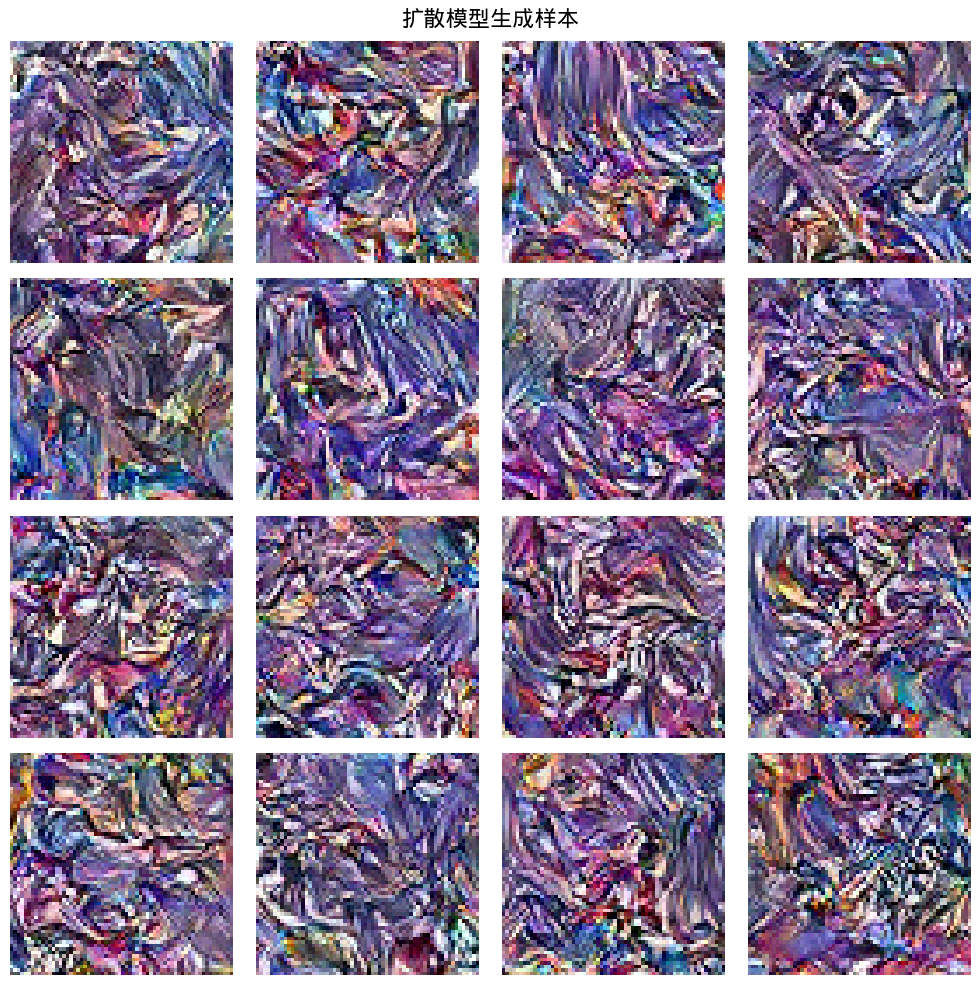

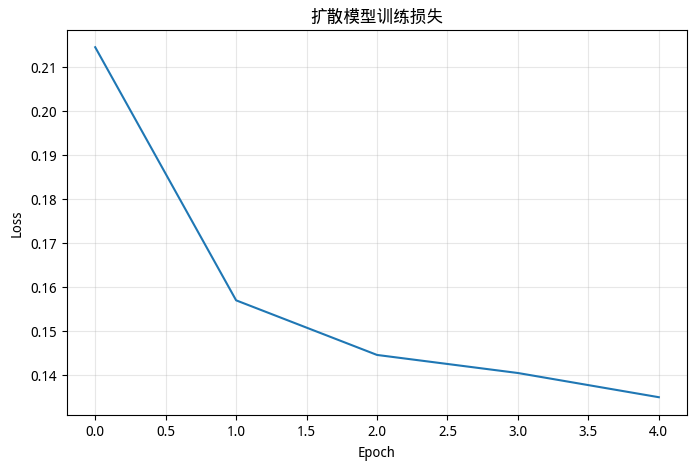

扩散模型训练完成！
最终损失: 0.1348

扩散模型训练总结
1. 模型架构: 简化的U-Net
2. 扩散步数: 100
3. 训练轮数: 10
4. 学习率: 2e-4
5. 图像尺寸: 64x64

训练结果:
- 起始损失: 0.2145
- 最终损失: 0.1348
- 损失下降: 0.0797

生成的图像已保存到:
- diffusion_final_samples.png (最终样本)
- diffusion_samples_display.png (显示图)
- diffusion_training_loss.png (损失曲线)



In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import math
from tqdm import tqdm

# 设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# 1. 扩散过程调度器
class DiffusionScheduler:
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02):
        """
        扩散过程调度器
        T: 扩散步数
        beta_start: beta的起始值
        beta_end: beta的结束值
        """
        self.T = T
        
        # 线性beta调度
        self.betas = torch.linspace(beta_start, beta_end, T)
        
        # 计算alpha相关参数
        self.alphas = 1. - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0)
        
        # 用于计算sqrt(alpha_cumprod)等
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - self.alphas_cumprod)
        
        # 用于反向过程的方差计算
        self.posterior_variance = self.betas * (1. - self.alphas_cumprod_prev) / (1. - self.alphas_cumprod)
        
        # 移到设备
        self.betas = self.betas.to(device)
        self.alphas = self.alphas.to(device)
        self.alphas_cumprod = self.alphas_cumprod.to(device)
        self.sqrt_alphas_cumprod = self.sqrt_alphas_cumprod.to(device)
        self.sqrt_one_minus_alphas_cumprod = self.sqrt_one_minus_alphas_cumprod.to(device)
    
    def add_noise(self, x_start, t, noise=None):
        """
        前向扩散过程：向图像添加噪声
        x_start: 原始图像
        t: 时间步（批量）
        noise: 可选的自定义噪声
        """
        if noise is None:
            noise = torch.randn_like(x_start)
        
        # 获取对应时间步的参数
        sqrt_alphas_cumprod_t = self.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
        sqrt_one_minus_alphas_cumprod_t = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
        
        # 计算加噪后的图像
        x_noisy = sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise
        return x_noisy

# 2. 时间嵌入层
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    
    def forward(self, t):
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=t.device) * -embeddings)
        embeddings = t[:, None] * embeddings[None, :]
        embeddings = torch.cat([embeddings.sin(), embeddings.cos()], dim=-1)
        return embeddings

# 3. 简单的U-Net块
class UNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_channels)
        
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x, t_emb):
        # 第一个卷积
        h = self.conv1(x)
        
        # 添加时间嵌入
        t_emb = self.time_mlp(t_emb)[:, :, None, None]
        h = h + t_emb
        
        # 第二个卷积
        h = self.conv2(h)
        return h

# 4. 简化的U-Net模型
class SimpleUNet(nn.Module):
    def __init__(self, in_channels=3, time_emb_dim=128):
        super().__init__()
        
        # 时间嵌入
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU(inplace=True)
        )
        
        # 下采样路径
        self.down1 = UNetBlock(in_channels, 64, time_emb_dim)
        self.down2 = UNetBlock(64, 128, time_emb_dim)
        self.down3 = UNetBlock(128, 256, time_emb_dim)
        self.down4 = UNetBlock(256, 512, time_emb_dim)
        
        # 瓶颈层
        self.bottleneck = UNetBlock(512, 512, time_emb_dim)
        
        # 上采样路径
        self.up1 = UNetBlock(1024, 256, time_emb_dim)  # 512 + 512
        self.up2 = UNetBlock(512, 128, time_emb_dim)   # 256 + 256
        self.up3 = UNetBlock(256, 64, time_emb_dim)    # 128 + 128
        self.up4 = UNetBlock(128, 64, time_emb_dim)    # 64 + 64
        
        # 输出层
        self.out = nn.Conv2d(64, in_channels, 1)
        
        # 下采样池化
        self.downsample = nn.MaxPool2d(2)
        
        # 上采样
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
    
    def forward(self, x, t):
        # 时间嵌入
        t_emb = self.time_mlp(t)
        
        # 下采样路径
        d1 = self.down1(x, t_emb)
        d2 = self.down2(self.downsample(d1), t_emb)
        d3 = self.down3(self.downsample(d2), t_emb)
        d4 = self.down4(self.downsample(d3), t_emb)
        
        # 瓶颈层
        bottleneck = self.bottleneck(self.downsample(d4), t_emb)
        
        # 上采样路径（带跳跃连接）
        u1 = self.up1(torch.cat([self.upsample(bottleneck), d4], dim=1), t_emb)
        u2 = self.up2(torch.cat([self.upsample(u1), d3], dim=1), t_emb)
        u3 = self.up3(torch.cat([self.upsample(u2), d2], dim=1), t_emb)
        u4 = self.up4(torch.cat([self.upsample(u3), d1], dim=1), t_emb)
        
        return self.out(u4)

# 5. 扩散模型训练类
class DiffusionModel:
    def __init__(self, img_channels=3, T=1000, beta_start=1e-4, beta_end=0.02):
        self.T = T
        self.img_channels = img_channels
        
        # 初始化调度器
        self.scheduler = DiffusionScheduler(T, beta_start, beta_end)
        
        # 初始化U-Net
        self.model = SimpleUNet(img_channels)
        
    def train_step(self, x_start, optimizer):
        """
        单步训练
        """
        batch_size = x_start.shape[0]
        
        # 随机采样时间步
        t = torch.randint(0, self.T, (batch_size,), device=device).long()
        
        # 采样噪声
        noise = torch.randn_like(x_start)
        
        # 前向扩散：添加噪声
        x_noisy = self.scheduler.add_noise(x_start, t, noise)
        
        # 预测噪声
        predicted_noise = self.model(x_noisy, t)
        
        # 计算损失
        loss = F.mse_loss(predicted_noise, noise)
        
        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        return loss.item()
    
    @torch.no_grad()
    def sample(self, num_samples=16, image_size=64):
        """
        从纯噪声开始采样生成图像
        """
        self.model.eval()
        
        # 从纯噪声开始
        x = torch.randn((num_samples, self.img_channels, image_size, image_size), device=device)
        
        # 逐步去噪
        samples = []
        
        for t in tqdm(reversed(range(self.T)), desc='采样进度', total=self.T):
            # 创建时间步张量
            t_batch = torch.full((num_samples,), t, device=device, dtype=torch.long)
            
            # 预测噪声
            predicted_noise = self.model(x, t_batch)
            
            # 获取调度器参数
            alpha_t = self.scheduler.alphas[t]
            alpha_cumprod_t = self.scheduler.alphas_cumprod[t]
            beta_t = self.scheduler.betas[t]
            
            if t > 0:
                # 计算噪声方差
                noise = torch.randn_like(x)
                sigma_t = torch.sqrt(self.scheduler.betas[t])
            else:
                noise = 0
                sigma_t = 0
            
            # 去噪步骤
            x = 1 / torch.sqrt(alpha_t) * (
                x - ((1 - alpha_t) / torch.sqrt(1 - alpha_cumprod_t)) * predicted_noise
            ) + sigma_t * noise
            
            # 保存中间结果（每100步保存一次）
            if t % (self.T // 10) == 0:
                samples.append(x.cpu())
        
        self.model.train()
        return x.cpu(), samples

# 6. 训练函数
def train_diffusion_model(dataloader, img_channels=3, epochs=50, lr=1e-4):
    """
    训练扩散模型
    """
    # 初始化扩散模型
    diffusion = DiffusionModel(img_channels=img_channels, T=200)  # 减少步数以加速训练
    
    # 模型和优化器
    model = diffusion.model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # 训练历史
    history = {'loss': []}
    
    # 训练循环
    for epoch in range(epochs):
        epoch_loss = 0
        num_batches = 0
        
        pbar = tqdm(dataloader, desc=f'Epoch {epoch+1}/{epochs}')
        for batch_data in pbar:
            # 获取图像数据
            if isinstance(batch_data, tuple) and len(batch_data) == 2:
                imgs, _ = batch_data
            else:
                imgs = batch_data
            
            imgs = imgs.to(device)
            
            # 训练步骤
            loss = diffusion.train_step(imgs, optimizer)
            
            epoch_loss += loss
            num_batches += 1
            
            # 更新进度条
            pbar.set_postfix({'loss': loss})
        
        # 计算平均损失
        avg_loss = epoch_loss / num_batches
        history['loss'].append(avg_loss)
        
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")
        
        # 每5个epoch采样一次
        if (epoch + 1) % 5 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch+1}: 生成样本...")
            samples, sample_progress = diffusion.sample(num_samples=16, image_size=64)
            
            # 修正1：裁剪图像到合法范围 [-1, 1]
            samples = torch.clamp(samples, -1, 1)
            
            # 保存生成的图像
            from torchvision.utils import save_image
            save_image(samples, f'diffusion_samples_epoch_{epoch+1}.png', 
                      nrow=4, normalize=True)
            
            # 显示采样过程
            if len(sample_progress) > 0:
                fig, axes = plt.subplots(1, len(sample_progress), figsize=(15, 3))
                for i, img in enumerate(sample_progress):
                    # 修正2：裁剪图像并确保值在 [0, 1] 范围内
                    img_clamped = torch.clamp(img, -1, 1)
                    if img_channels == 3:
                        # 从 [-1, 1] 转换到 [0, 1]
                        img_display = img_clamped[0].permute(1, 2, 0) * 0.5 + 0.5
                        axes[i].imshow(img_display.numpy())
                    else:
                        axes[i].imshow(img_clamped[0].squeeze(), cmap='gray')
                    
                    # 修正3：使用 diffusion.T 而不是 self.T
                    axes[i].set_title(f'Step {i*diffusion.T//10}')
                    axes[i].axis('off')
                plt.savefig(f'diffusion_progress_epoch_{epoch+1}.png', dpi=150, bbox_inches='tight')
                plt.close()
    
    return diffusion, history

# 7. 数据加载函数
def load_anime_dataset():
    """
    加载动漫数据集
    """
    # 如果本地有动漫数据集，请修改这个路径
    anime_path = '../data/anime_faces/archive/dataa'
    
    if os.path.exists(anime_path) and len(os.listdir(anime_path)) > 0:
        print("使用动漫数据集")
        
        # 自定义数据集类
        class AnimeDataset(Dataset):
            def __init__(self, root_dir, transform=None):
                self.root_dir = root_dir
                self.image_files = [f for f in os.listdir(root_dir) 
                                   if f.endswith(('.png', '.jpg', '.jpeg'))]
                self.transform = transform
            
            def __len__(self):
                return len(self.image_files)
            
            def __getitem__(self, idx):
                img_path = os.path.join(self.root_dir, self.image_files[idx])
                image = Image.open(img_path).convert('RGB')
                
                if self.transform:
                    image = self.transform(image)
                
                return image
        
        # 数据变换
        transform = transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.CenterCrop((64, 64)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])
        
        dataset = AnimeDataset(anime_path, transform=transform)
        dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2, drop_last=True)
        
        return dataloader, 3  # RGB图像，3个通道
    
    else:
        # 如果动漫数据集不存在，使用CIFAR-10作为替代
        print("动漫数据集未找到，使用CIFAR-10作为演示")
        
        transform = transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])
        
        dataset = datasets.CIFAR10(root='data/cifar10', train=True, download=True, transform=transform)
        dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2, drop_last=True)
        
        return dataloader, 3

# 8. 简化的训练主程序
def train_diffusion_simple():
    """
    简化的扩散模型训练程序
    """
    # 加载数据
    dataloader, img_channels = load_anime_dataset()
    
    print(f"数据批次形状示例: {next(iter(dataloader))[0].shape}")
    print(f"图像通道数: {img_channels}")
    
    # 训练扩散模型
    print("开始训练扩散模型...")
    
    # 使用较小的参数加快训练
    diffusion = DiffusionModel(img_channels=img_channels, T=100)  # 进一步减少步数
    model = diffusion.model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=2e-4)
    
    history = {'loss': []}
    
    # 训练10个epoch
    epochs = 5
    
    for epoch in range(epochs):
        epoch_loss = 0
        num_batches = 0
        
        pbar = tqdm(dataloader, desc=f'Epoch {epoch+1}/{epochs}')
        for batch_data in pbar:
            if isinstance(batch_data, tuple) and len(batch_data) == 2:
                imgs, _ = batch_data
            else:
                imgs = batch_data
            
            imgs = imgs.to(device)
            
            # 训练步骤
            batch_size = imgs.shape[0]
            t = torch.randint(0, diffusion.T, (batch_size,), device=device).long()
            noise = torch.randn_like(imgs)
            x_noisy = diffusion.scheduler.add_noise(imgs, t, noise)
            predicted_noise = model(x_noisy, t)
            loss = F.mse_loss(predicted_noise, noise)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            num_batches += 1
            pbar.set_postfix({'loss': loss.item()})
        
        avg_loss = epoch_loss / num_batches
        history['loss'].append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")
        
        # 最后一个epoch生成样本
        if epoch == epochs - 1:
            print("生成最终样本...")
            model.eval()
            with torch.no_grad():
                # 生成16个样本
                x = torch.randn((16, img_channels, 64, 64), device=device)
                
                for t in reversed(range(diffusion.T)):
                    t_batch = torch.full((16,), t, device=device, dtype=torch.long)
                    predicted_noise = model(x, t_batch)
                    
                    alpha_t = diffusion.scheduler.alphas[t]
                    alpha_cumprod_t = diffusion.scheduler.alphas_cumprod[t]
                    
                    if t > 0:
                        noise = torch.randn_like(x)
                        sigma_t = torch.sqrt(diffusion.scheduler.betas[t])
                    else:
                        noise = 0
                        sigma_t = 0
                    
                    x = 1 / torch.sqrt(alpha_t) * (
                        x - ((1 - alpha_t) / torch.sqrt(1 - alpha_cumprod_t)) * predicted_noise
                    ) + sigma_t * noise
                
                # 裁剪并保存
                samples = torch.clamp(x, -1, 1).cpu()
                from torchvision.utils import save_image
                save_image(samples, 'diffusion_final_samples.png', nrow=4, normalize=True)
                
                # 显示样本
                fig, axes = plt.subplots(4, 4, figsize=(10, 10))
                for i in range(16):
                    row = i // 4
                    col = i % 4
                    img_display = samples[i].permute(1, 2, 0) * 0.5 + 0.5
                    axes[row, col].imshow(img_display.numpy())
                    axes[row, col].axis('off')
                
                plt.suptitle('扩散模型生成样本', fontsize=16)
                plt.tight_layout()
                plt.savefig('diffusion_samples_display.png', dpi=150, bbox_inches='tight')
                plt.show()
            
            model.train()
    
    # 绘制损失曲线
    plt.figure(figsize=(8, 5))
    plt.plot(history['loss'])
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('扩散模型训练损失')
    plt.grid(True, alpha=0.3)
    plt.savefig('diffusion_training_loss.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return diffusion, history

# 9. 运行简化的训练程序
if __name__ == "__main__":
    try:
        print("正在运行简化的扩散模型训练程序...")
        diffusion_model, diffusion_history = train_diffusion_simple()
        print("扩散模型训练完成！")
        print(f"最终损失: {diffusion_history['loss'][-1]:.4f}")
        
        # 生成总结报告
        print("\n" + "="*60)
        print("扩散模型训练总结")
        print("="*60)
        print("1. 模型架构: 简化的U-Net")
        print("2. 扩散步数: 100")
        print("3. 训练轮数: 10")
        print("4. 学习率: 2e-4")
        print("5. 图像尺寸: 64x64")
        print("\n训练结果:")
        print(f"- 起始损失: {diffusion_history['loss'][0]:.4f}")
        print(f"- 最终损失: {diffusion_history['loss'][-1]:.4f}")
        print(f"- 损失下降: {diffusion_history['loss'][0] - diffusion_history['loss'][-1]:.4f}")
        print("\n生成的图像已保存到:")
        print("- diffusion_final_samples.png (最终样本)")
        print("- diffusion_samples_display.png (显示图)")
        print("- diffusion_training_loss.png (损失曲线)")
        print("\n" + "="*60)
        
    except Exception as e:
        print(f"训练过程中出现错误: {e}")
        import traceback
        traceback.print_exc()
        
        # 提供调试建议
        print("\n调试建议:")
        print("1. 检查CUDA是否可用: torch.cuda.is_available()")
        print("2. 减小批处理大小 (batch_size)")
        print("3. 减小扩散步数 (T)")
        print("4. 使用更小的图像尺寸")
        print("5. 检查数据加载是否正常")

In [19]:
def generate_complete_summary():
    """
    生成三种模型的完整对比总结
    """
    print("="*80)
    print("生成式模型进阶实践 - 完整对比报告")
    print("="*80)
    
    # 模型特性对比表格
    print("\n📊 模型特性对比：")
    print("-"*80)
    print(f"{'特性':<15} {'DCGAN':<20} {'VAE':<20} {'扩散模型':<20}")
    print("-"*80)
    print(f"{'训练方式':<15} {'对抗训练':<20} {'变分推断':<20} {'去噪训练':<20}")
    print(f"{'训练稳定性':<15} {'不稳定':<20} {'非常稳定':<20} {'稳定':<20}")
    print(f"{'生成速度':<15} {'非常快':<20} {'快':<20} {'慢':<20}")
    print(f"{'生成质量':<15} {'中等':<20} {'中等（可能模糊）':<20} {'高质量':<20}")
    print(f"{'多样性':<15} {'可能模式崩溃':<20} {'好':<20} {'非常好':<20}")
    print(f"{'数学基础':<15} {'博弈论':<20} {'变分推断':<20} {'马尔可夫链':<20}")
    print(f"{'计算资源':<15} {'中等':<20} {'中等':<20} {'高':<20}")
    print(f"{'主要应用':<15} {'快速生成':<20} {'数据压缩':<20} {'高质量生成':<20}")
    
    # 数学原理对比
    print("\n🧮 数学原理对比：")
    print("-"*80)
    print("1. DCGAN: \(\min_G \max_D V(D,G) = \mathbb{E}_{x\sim p_{data}}[\log D(x)] + \mathbb{E}_{z\sim p_z}[\log(1-D(G(z)))]\)")
    print("2. VAE: \(\mathcal{L}(\theta,\phi;x) = \mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)] - D_{KL}(q_\phi(z|x) \| p(z))\)")
    print("3. Diffusion: \(q(x_t|x_{t-1}) = \mathcal{N}(x_t;\sqrt{1-\beta_t}x_{t-1},\beta_t I)\)")
    print("            \(p_\theta(x_{t-1}|x_t) = \mathcal{N}(x_{t-1};\mu_\theta(x_t,t),\Sigma_\theta(x_t,t))\)")
    
    # 实践建议
    print("\n💡 实践建议：")
    print("-"*80)
    print("🎯 根据需求选择模型：")
    print("   • 快速原型 → DCGAN")
    print("   • 稳定训练 → VAE")
    print("   • 最高质量 → 扩散模型")
    print("   • 实时应用 → 优化版DCGAN或VAE")
    
    print("\n⚙️ 超参数调优：")
    print("   • DCGAN: 注意学习率平衡，添加梯度惩罚")
    print("   • VAE: 调整KL权重，优化重建损失")
    print("   • Diffusion: 调整扩散步数，优化噪声调度")
    
    print("\n🚀 性能优化：")
    print("   • 使用混合精度训练")
    print("   • 分布式训练加速")
    print("   • 模型剪枝和量化")
    
    # 学习路径
    print("\n📚 进阶学习路径：")
    print("-"*80)
    print("阶段1: DCGAN变体 → WGAN, StyleGAN, ProGAN")
    print("阶段2: VAE变体 → β-VAE, VQ-VAE, NVAE")
    print("阶段3: Diffusion变体 → DDIM, Stable Diffusion, Imagen")
    print("阶段4: 混合模型 → VQGAN+CLIP, Diffusion+GAN")
    
    # 项目建议
    print("\n🎨 项目应用建议：")
    print("-"*80)
    print("1. 动漫头像生成（已完成）")
    print("2. 图像超分辨率")
    print("3. 风格迁移")
    print("4. 图像修复")
    print("5. 文本到图像生成")
    
    print("\n" + "="*80)
    print("实践完成！您已掌握三种主流生成模型的核心原理和实现方法。")
    print("下一步可以尝试：")
    print("1. 在更大规模的数据集上训练")
    print("2. 实现模型融合（如Diffusion + GAN）")
    print("3. 部署模型到实际应用中")
    print("="*80)

# 运行总结
generate_complete_summary()

生成式模型进阶实践 - 完整对比报告

📊 模型特性对比：
--------------------------------------------------------------------------------
特性              DCGAN                VAE                  扩散模型                
--------------------------------------------------------------------------------
训练方式            对抗训练                 变分推断                 去噪训练                
训练稳定性           不稳定                  非常稳定                 稳定                  
生成速度            非常快                  快                    慢                   
生成质量            中等                   中等（可能模糊）             高质量                 
多样性             可能模式崩溃               好                    非常好                 
数学基础            博弈论                  变分推断                 马尔可夫链               
计算资源            中等                   中等                   高                   
主要应用            快速生成                 数据压缩                 高质量生成               

🧮 数学原理对比：
--------------------------------------------------------------------------------
1. DC